# Modeling (Jordan Blackman)

Using Nutrition Information to Classify Brand Tier (Premium Foods)

Mia Arnold - Jordan Blackman - Allen Ros

Shirley Marcos School of Engineering, University of San Diego

ADS-502 Applied Data Mining

# Goals

1. Data type transformation, remove features that would lead to overfitting, test train split, SMOTENC(nominal and continuous), Encoding, and Scaling.

2. Establish Baseline Model and evaluation metrics

3. Train initial models, tune hyperparameters (max leaf, minobservations, C for regularization), explore cost matrices, and explore bagging and boosting

4. Compare all models across multiple metrics beyond accuracy

Models to explore: Baseline (Majority Class), Naive Bayes, Decision Tree (CART, C5.0), kNN Classifier, Logistic Regression, SVC (Linear), SVC (RBF), SVC (Polynamial), SVC (Sigmoid), Random Forest Classifier (with bagging and boosting), XGBoost, Adaboost, and Neural Network.

# Data Type Transformation and Removing Overfitting Features

In [7]:
# import the necessary packages
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("food_menu_nutrition_dataset.csv")

# log price, protein, and sugars to handle significant skew
df['log_price_usd_normalized'] = np.log1p(df['price_usd_normalized'])
df['log_protein_g'] = np.log1p(df['protein_g'])
df['log_sugars_g'] = np.log1p(df['sugars_g'])

# square root serving size, calories, fat, carbs, sodium to handle small skew
df['sqrt_serving_size_g'] = np.sqrt(df['serving_size_g'])
df['sqrt_calories'] = np.sqrt(df['calories'])
df['sqrt_total_fat_g'] = np.sqrt(df['total_fat_g'])
df['sqrt_total_carbs_g'] = np.sqrt(df['total_carbs_g'])
df['sqrt_sodium_mg'] = np.sqrt(df['sodium_mg'])

# flip average rating to handle left skew, units are flipped
reflect_constant = df['avg_rating'].max() + 1
df['trans_avg_rating'] = np.sqrt(reflect_constant - df['avg_rating'])

# is_bestseller is the only numerical variable left alone

# drop all original columns that were transformed
df = df.drop(columns=['price_usd_normalized', 'protein_g', 'sugars_g',
                      'serving_size_g', 'calories', 'total_fat_g',
                      'total_carbs_g', 'sodium_mg', 'avg_rating'])

# set up items that are nto being used for training models
items_to_drop = ['item_name', 'city', 'brand_name',
                 'brand_tier']

# get dependent and independent variables
Y = (df['brand_tier'] == 'premium').astype(int)
X = df.drop(columns=items_to_drop)

# view the data
df.head().T

,0,1,2,3,4,5,6,7,8,9,...,7490,7491,7492,7493,7494,7495,7496,7497,7498,7499
item_name,Veggie Sub,Waffles with Syrup,Grilled Chicken Salad,Waffles with Syrup,Chocolate Brownie,Paneer Tikka Pizza,Tiramisu,Meat Lovers Pizza,Fish Fillet Burger,Teriyaki Chicken Bowl,...,Lemonade,Caesar Salad with Chicken,French Fries,Mac and Cheese,Quinoa Salad,Vegan BLT,Vanilla Shake,Crispy Chicken Burger,Vanilla Shake,Oat Milk Latte
item_category,Sandwich,Dessert,Salad,Dessert,Dessert,Pizza,Dessert,Pizza,Burger,Rice/Bowl,...,Drink,Salad,Sides,Sides,Salad,Sandwich,Drink,Burger,Drink,Drink
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg,Veg,Non-Veg,Non-Veg,Non-Veg,Non-Veg,...,Veg,Non-Veg,Veg,Veg,Vegan,Vegan,Veg,Non-Veg,Veg,Vegan
brand_name,Five Guys,KFC,Domino's,Five Guys,Subway,Five Guys,Domino's,Taco Bell,Pizza Hut,Subway,...,Pizza Hut,TGI Fridays,Shake Shack,Ruth's Chris Steakhouse,Applebee's,Burger King,Gordon Ramsay Bar & Grill,Nando's,Taco Bell,Shake Shack
brand_tier,mid,budget,budget,mid,budget,mid,budget,budget,budget,budget,...,budget,mid,mid,premium,mid,budget,premium,mid,budget,mid
country,UK,USA,Canada,USA,USA,Canada,UK,UK,USA,Canada,...,USA,Canada,USA,India,India,India,USA,India,USA,Canada
city,London,Austin,Toronto,Chicago,Chicago,Windsor,Birmingham,Exeter,Portland,Toronto,...,Boise,Saskatoon,New York,Indore,Mumbai,Chennai,Boise,Pune,Spokane,Edmonton
city_tier,metro,tier-2,metro,metro,metro,tier-3,tier-2,tier-3,tier-2,metro,...,tier-3,tier-3,metro,tier-3,metro,tier-2,tier-3,tier-2,tier-3,tier-2
is_bestseller,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
log_price_usd_normalized,2.267994,1.329724,1.912501,2.248129,1.332366,2.291524,2.065596,1.774952,2.213754,1.742219,...,1.806648,2.843746,2.40243,2.080691,1.880991,1.196948,3.340385,2.188296,1.467874,1.747459


# Test Train Split

In [8]:
# test train split with random state and stratification
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

# SMOTE

In [9]:
# Oversample the minority class (Premium)
from imblearn.over_sampling import SMOTENC

cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.drop(
    items_to_drop, errors='ignore').tolist()

cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

print("Before SMOTE")
print(Y_train.value_counts())

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train, Y_train = smote_nc.fit_resample(X_train, Y_train)

print("After SMOTE:")
print(Y_train.value_counts())

Before SMOTE
brand_tier
0    5404
1     596
Name: count, dtype: int64
After SMOTE:
brand_tier
0    5404
1    5404
Name: count, dtype: int64


# Encoding

In [10]:
# encode variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# align encoded variables
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0)

# Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# scale variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Establish Evaluation Function

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# define a reusable function to calculate evaluation metrics for all models


def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model", verbose=True):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    roc_auc = None
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)

    if verbose:
        print(f"--- {model_name} Evaluation ---")
        print(f"Accuracy:    {acc:.4f}")
        print(f"Precision:   {prec:.4f}")
        print(f"Recall:      {rec:.4f} (Sensitivity)")
        print(f"Specificity: {specificity:.4f}")
        print(f"F1-Score:    {f1:.4f}")

        if roc_auc is not None:
            print(f"ROC AUC:     {roc_auc:.4f}")

        print("-" * 30 + "\n")

        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

# Establish Reusable Modeling Function

In [13]:
# establish a function trains and evaluates all models
def train_and_evaluate(model, x_train, y_train, x_test, y_test, model_name, verbose=True):

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_prob, model_name, verbose)

    return metrics

# Establish Baseline Model

--- Baseline (Majority Class) Evaluation ---
Accuracy:    0.9007
Precision:   0.0000
Recall:      0.0000 (Sensitivity)
Specificity: 1.0000
F1-Score:    0.0000
ROC AUC:     0.5000
------------------------------



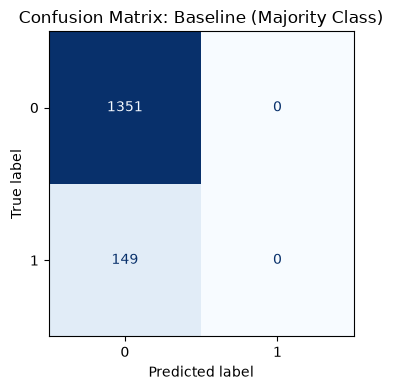

In [14]:
# dummy model always predicts the majority class
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="constant", constant=0)

baseline_metrics = train_and_evaluate(
    baseline,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="Baseline (Majority Class)"
)

# Train Initial Models

--- Naive Bayes 1 Evaluation ---
Accuracy:    0.8227
Precision:   0.3107
Recall:      0.6443 (Sensitivity)
Specificity: 0.8423
F1-Score:    0.4192
ROC AUC:     0.8071
------------------------------



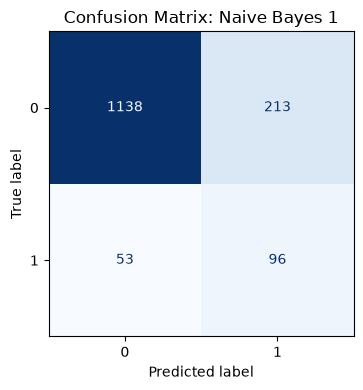

In [15]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_1 = GaussianNB()

nb_1_metrics = train_and_evaluate(
    nb_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Naive Bayes 1"
)

--- Cart 1 Evaluation ---
Accuracy:    0.9227
Precision:   0.5727
Recall:      0.8725 (Sensitivity)
Specificity: 0.9282
F1-Score:    0.6915
ROC AUC:     0.9003
------------------------------



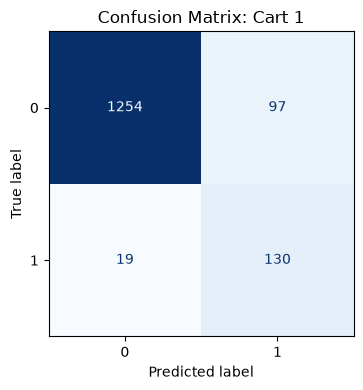

In [16]:
# Decision Tree (CART)

from sklearn.tree import DecisionTreeClassifier

cart_1 = DecisionTreeClassifier(random_state=42, class_weight=None)

cart_1_metrics = train_and_evaluate(
    cart_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Cart 1"
)

--- C5.0 1 Evaluation ---
Accuracy:    0.9220
Precision:   0.5696
Recall:      0.8792 (Sensitivity)
Specificity: 0.9267
F1-Score:    0.6913
ROC AUC:     0.9030
------------------------------



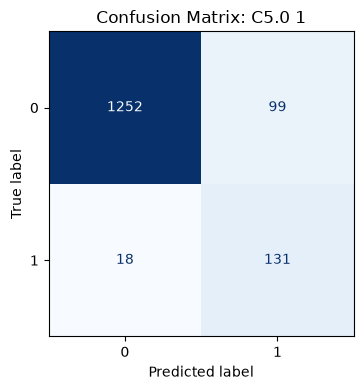

In [17]:
# Decision Tree (C5.0)

cart_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

c5_metrics = train_and_evaluate(
    cart_entropy,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="C5.0 1"
)

--- KNN (n=4) Evaluation ---
Accuracy:    0.8540
Precision:   0.3465
Recall:      0.5302 (Sensitivity)
Specificity: 0.8897
F1-Score:    0.4191
ROC AUC:     0.8021
------------------------------



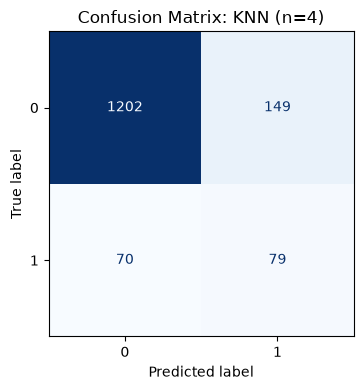

In [18]:
# kNN Classifier (selected)
from sklearn.neighbors import KNeighborsClassifier

knn_1 = KNeighborsClassifier(n_neighbors=4)

knn_metrics = train_and_evaluate(
    knn_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="KNN (n=4)"
)

--- Logistic Regression Evaluation ---
Accuracy:    0.9173
Precision:   0.5486
Recall:      0.9463 (Sensitivity)
Specificity: 0.9141
F1-Score:    0.6946
ROC AUC:     0.9842
------------------------------



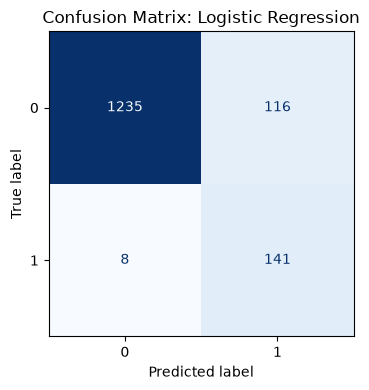

In [19]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_reg_1 = LogisticRegression(random_state=42, max_iter=1000)

log_reg_1_metrics = train_and_evaluate(
    log_reg_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Logistic Regression"

)

--- SVC Linear Evaluation ---
Accuracy:    0.9140
Precision:   0.5391
Recall:      0.9262 (Sensitivity)
Specificity: 0.9127
F1-Score:    0.6815
ROC AUC:     0.9818
------------------------------



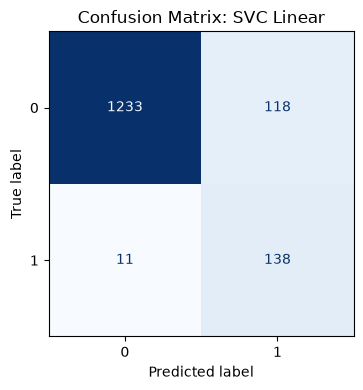

In [20]:
# SVC (Linear)

from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

base_svc_linear = SVC(kernel='linear', random_state=42)
svc_linear = CalibratedClassifierCV(base_svc_linear, ensemble=False)

svc_linear_metrics = train_and_evaluate(
    svc_linear,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC Linear"
)

--- SVC RBF Evaluation ---
Accuracy:    0.9293
Precision:   0.6070
Recall:      0.8188 (Sensitivity)
Specificity: 0.9415
F1-Score:    0.6971
ROC AUC:     0.9698
------------------------------



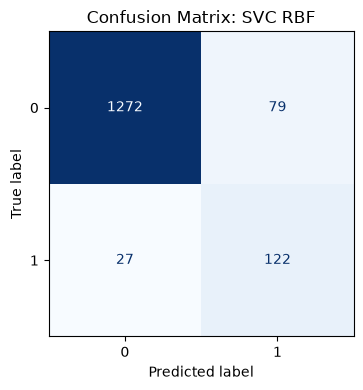

In [21]:
# SVC (RBF)
base_svc_rbf = SVC(kernel='rbf', random_state=42)
svc_rbf = CalibratedClassifierCV(base_svc_rbf, ensemble=False)

svc_rbf_metrics = train_and_evaluate(
    svc_rbf,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC RBF"
)

--- SVC Polynomial Evaluation ---
Accuracy:    0.9300
Precision:   0.6058
Recall:      0.8456 (Sensitivity)
Specificity: 0.9393
F1-Score:    0.7059
ROC AUC:     0.9712
------------------------------



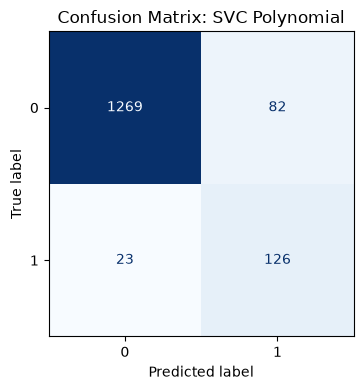

In [22]:
# SVC (Polynomial)
base_svc_poly = SVC(kernel='poly', random_state=42)
svc_poly = CalibratedClassifierCV(base_svc_poly, ensemble=False)

svc_poly_metrics = train_and_evaluate(
    svc_poly,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC Polynomial"
)

--- SVC Sigmoid Evaluation ---
Accuracy:    0.8300
Precision:   0.3494
Recall:      0.8255 (Sensitivity)
Specificity: 0.8305
F1-Score:    0.4910
ROC AUC:     0.8940
------------------------------



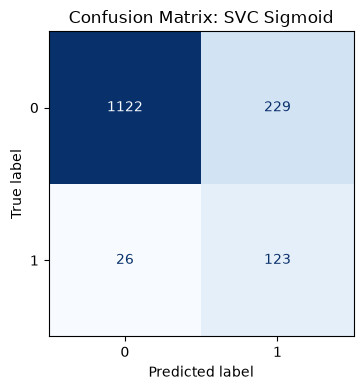

In [23]:
# SVC (Sigmoid)
base_svc_sigmoid = SVC(kernel='sigmoid', random_state=42)
svc_sigmoid = CalibratedClassifierCV(base_svc_sigmoid, ensemble=False)

svc_sigmoid_metrics = train_and_evaluate(
    svc_sigmoid,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="SVC Sigmoid"
)

--- Random Forest Evaluation ---
Accuracy:    0.9453
Precision:   0.6811
Recall:      0.8456 (Sensitivity)
Specificity: 0.9563
F1-Score:    0.7545
ROC AUC:     0.9728
------------------------------



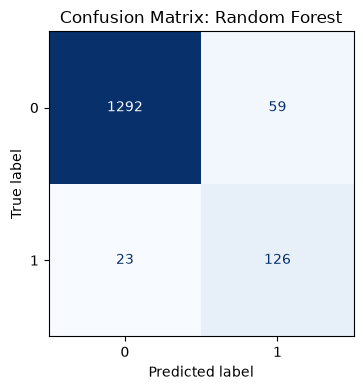

In [24]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_metrics = train_and_evaluate(
    rf_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Random Forest"
)

--- Balanced Random Forest Evaluation ---
Accuracy:    0.9453
Precision:   0.6791
Recall:      0.8523 (Sensitivity)
Specificity: 0.9556
F1-Score:    0.7560
ROC AUC:     0.9718
------------------------------



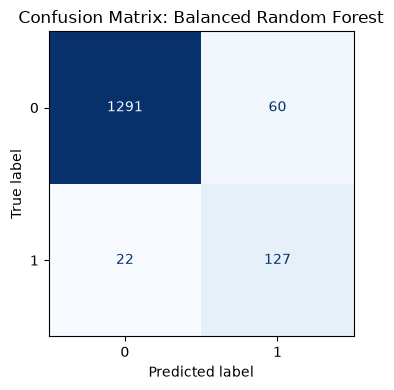

In [25]:
# Balanced Random Forest Classifier
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)

brf_metrics = train_and_evaluate(
    brf,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Balanced Random Forest"
)

/opt/anaconda3/envs/ads502/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:12:38] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Evaluation ---
Accuracy:    0.9553
Precision:   0.7330
Recall:      0.8658 (Sensitivity)
Specificity: 0.9652
F1-Score:    0.7938
ROC AUC:     0.9810
------------------------------



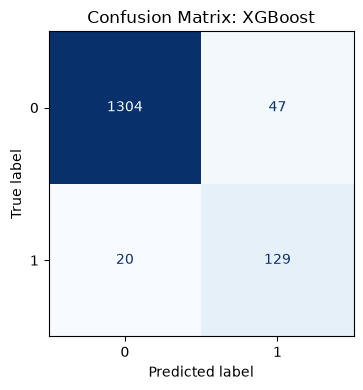

In [26]:
# XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_metrics = train_and_evaluate(
    xgb_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="XGBoost"
)

--- AdaBoost Evaluation ---
Accuracy:    0.8660
Precision:   0.4198
Recall:      0.9128 (Sensitivity)
Specificity: 0.8608
F1-Score:    0.5751
ROC AUC:     0.9678
------------------------------



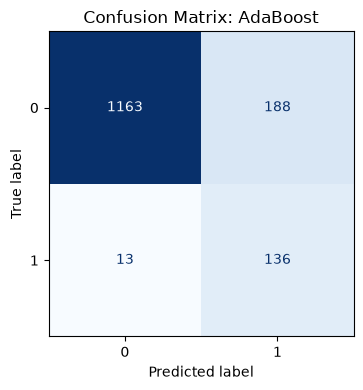

In [27]:
# AdaBoost with Random Forest Base

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_metrics = train_and_evaluate(
    ada_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="AdaBoost"
)

--- Neural Network (Regularized) Evaluation ---
Accuracy:    0.9280
Precision:   0.5911
Recall:      0.8926 (Sensitivity)
Specificity: 0.9319
F1-Score:    0.7112
ROC AUC:     0.9790
------------------------------



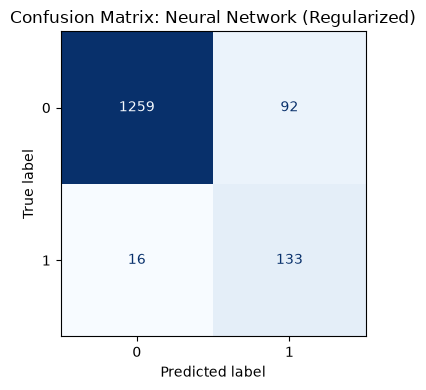

In [28]:
# Neural Network

from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.05,
    max_iter=1000,
    learning_rate_init=0.001,
    early_stopping=True,
    random_state=42
)

mlp_metrics = train_and_evaluate(
    mlp_model,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Neural Network (Regularized)"
)

# Compare Initial Models

In [29]:
# Compare all model results
model_results = [val for name, val in globals().items(
) if 'metrics' in name and isinstance(val, dict)]

# 2. Convert to DataFrame
results_df = pd.DataFrame(model_results)

# 3. Set the 'model' column as the index for better readability
results_df.set_index('model', inplace=True)

# 4. Display the table
results_df.sort_values(by='roc_auc', ascending=False). round(2)

,accuracy,precision,recall,specificity,f1_score,roc_auc
model,,,,,,
Logistic Regression,0.92,0.55,0.95,0.91,0.69,0.98
SVC Linear,0.91,0.54,0.93,0.91,0.68,0.98
XGBoost,0.96,0.73,0.87,0.97,0.79,0.98
Neural Network (Regularized),0.93,0.59,0.89,0.93,0.71,0.98
Random Forest,0.95,0.68,0.85,0.96,0.75,0.97
Balanced Random Forest,0.95,0.68,0.85,0.96,0.76,0.97
SVC Polynomial,0.93,0.61,0.85,0.94,0.71,0.97
SVC RBF,0.93,0.61,0.82,0.94,0.70,0.97
AdaBoost,0.87,0.42,0.91,0.86,0.58,0.97


# Explore Hyperparameters and Cost Matrices

In [30]:
# kNN Classifier tuning k

all_results = []

for k in range(1, 101):
    knn = KNeighborsClassifier(n_neighbors=k)

    metrics = train_and_evaluate(
        knn, X_train_scaled, Y_train, X_test_scaled, Y_test,
        model_name=f"k={k}", verbose=False
    )
    all_results.append(metrics)

df = pd.DataFrame(all_results)

df['k'] = df['model'].str.extract('(\d+)').astype(int)

metrics_to_check = ['accuracy', 'precision',
                    'recall', 'specificity',
                    'f1_score', 'roc_auc']

for metric in metrics_to_check:
    print(f"--- Top 2 k-values for {metric.upper()} ---")

    top_2 = df.nlargest(2, metric)

    for i, row in top_2.iterrows():
        print(f"Rank {i+1}: k = {row['k']} | Score = {row[metric]:.4f}")
    print("\n")

--- Top 2 k-values for ACCURACY ---
Rank 2: k = 2 | Score = 0.8707
Rank 4: k = 4 | Score = 0.8540


--- Top 2 k-values for PRECISION ---
Rank 2: k = 2 | Score = 0.3784
Rank 4: k = 4 | Score = 0.3465


--- Top 2 k-values for RECALL ---
Rank 59: k = 59 | Score = 0.7651
Rank 61: k = 61 | Score = 0.7651


--- Top 2 k-values for SPECIFICITY ---
Rank 2: k = 2 | Score = 0.9149
Rank 4: k = 4 | Score = 0.8897


--- Top 2 k-values for F1_SCORE ---
Rank 11: k = 11 | Score = 0.4226
Rank 3: k = 3 | Score = 0.4203


--- Top 2 k-values for ROC_AUC ---
Rank 55: k = 55 | Score = 0.8385
Rank 56: k = 56 | Score = 0.8384




Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'colsample_bytree': np.float64(0.6053059844639466), 'learning_rate': np.float64(0.29266052670545584), 'max_depth': 8, 'n_estimators': 291, 'subsample': np.float64(0.7541666010159664)}
--- Tuned XGBoost Evaluation ---
Accuracy:    0.9707
Precision:   0.8477
Recall:      0.8591 (Sensitivity)
Specificity: 0.9830
F1-Score:    0.8533
ROC AUC:     0.9771
------------------------------



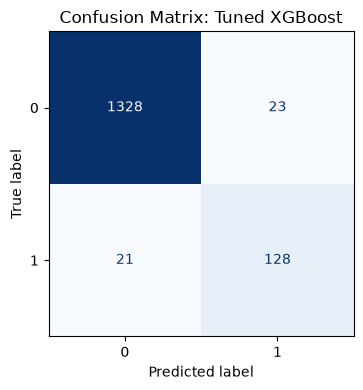

In [31]:
# XGBoost with tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

param_dist = {
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'n_estimators': randint(50, 300),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_scaled, Y_train)

print(f"Best Parameters: {random_search.best_params_}")

best_xgb = random_search.best_estimator_
xgb_metrics = train_and_evaluate(
    best_xgb,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Tuned XGBoost"
)

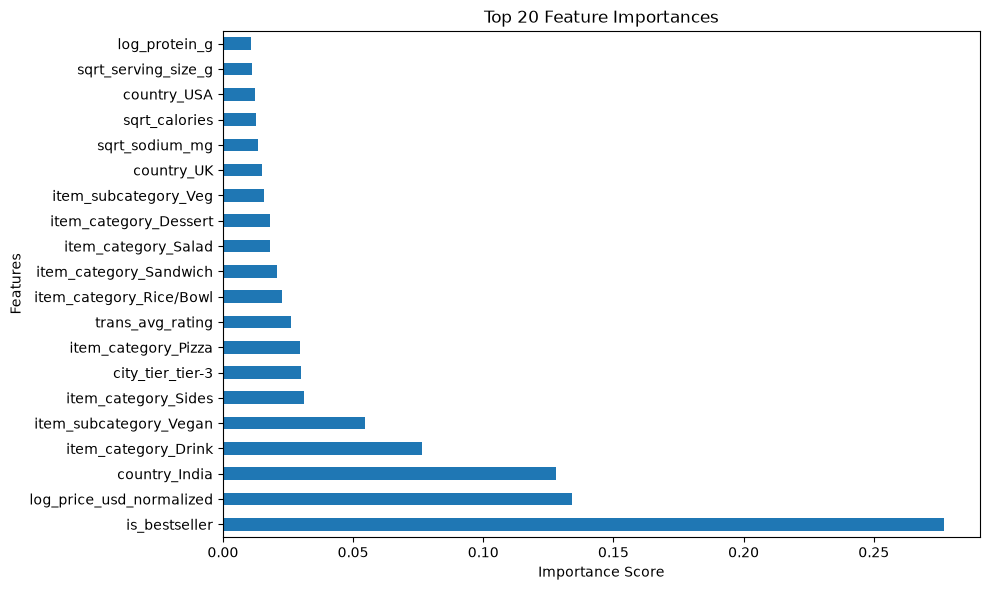

In [32]:
# Get feature importances
importances = best_xgb.feature_importances_

feature_names = X_train_encoded.columns

feat_imp = pd.Series(
    importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh', title="Top 20 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

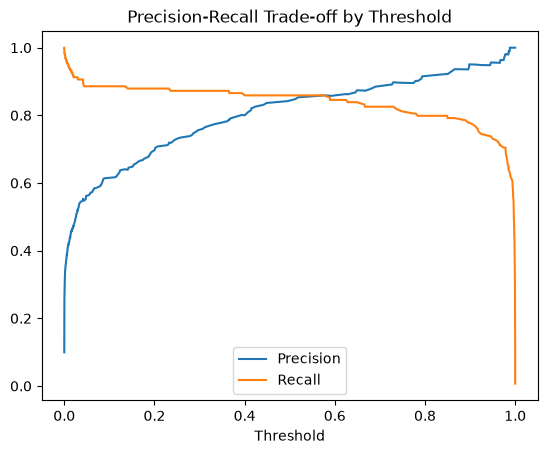

In [33]:
from sklearn.metrics import precision_recall_curve
y_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate Precision, Recall, and Thresholds
precision, recall, thresholds = precision_recall_curve(Y_test, y_probs)

# 3. Find the threshold that balances precision and recall
# (e.g., maximizing the F1 score or finding a specific precision level)
# Here is a plot to visualize the trade-off:
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall Trade-off by Threshold")
plt.show()

# Compare all models